# Figure 2

In [1]:
import pandas as pd
import sys
sys.path.append('/home/ls2543/python_packages')
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('final_group_pos_doipmid_puby_deltadays_field_tsize_top5_before0_after1_coauthor_wc0_natindex_fpy_aca_exp_jif_EISSN.csv')

df = df[(df['DeltaDays'] > 0) & (df['DeltaDays'] <= 20000)].copy()

df['year_diff'] = abs(df['PubYear'] - df['awardYear'])

df['is_nature_index'] = df['is_nature_index'].fillna(2).astype('category')
df['JournalISSN'] = df['JournalISSN'].fillna("Unknown")
df['author_position'] = pd.Categorical(df['author_position'], categories=["first", "middle", "last"])
df['field'] = df['field'].astype('category')
df['is_top5'] = df['is_top5'].astype('category')

df

/tmp/ipykernel_2975428/3964898150.py:6: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('final_group_pos_doipmid_puby_deltadays_field_tsize_top5_before0_after1_coauthor_wc0_natindex_fpy_aca_exp_jif_EISSN.csv')


,group_id,author_id,if_winner,work_id,author_position,doi,pmid,JournalISSN,PubYear,DeltaDays,...,winner_count,cited_by_count,ref_num,first_pub_year,academic_experience,JournalISSN_clean,year_diff,is_nature_index,JIF,JIF5Years
0,1.0,A100328954,1,W2064862591,last,j.bpj.2009.04.054,19619467.0,1542-0086,2009.0,34.0,...,1,15,46,1968,41.0,15420086,7.0,0.0,3.2,3.2
1,1.0,A100328954,1,W1948327735,last,gkv739,26184876.0,1362-4962,2015.0,64.0,...,1,3,19,1968,47.0,13624962,1.0,0.0,16.6,16.1
2,1.0,A100328954,1,W2761930832,last,j.chembiol.2017.08.018,28988948.0,2451-9448,2017.0,95.0,...,1,12,36,1968,49.0,24519448,1.0,0.0,6.6,8.2
3,1.0,A100328954,1,W2079983821,last,nature10500,21993758.0,1476-4687,2011.0,301.0,...,1,92,26,1968,43.0,14764687,5.0,1.0,50.5,54.4
4,1.0,A100328954,1,W2626909667,middle,s41467-017-00070-0,28623249.0,2041-1723,2017.0,11.0,...,1,43,34,1968,49.0,20411723,1.0,1.0,14.7,16.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1168803,1778.0,A1979552405,0,W2131927690,last,10.1017/s1431927606060491,16984669.0,1431-9276,2006.0,447.0,...,0,19,17,1992,14.0,14319276,4.0,0.0,2.9,3.4
1168804,1778.0,A2109096116,0,W2149846440,middle,10.1038/nmat3234,22306770.0,1476-4660,2012.0,120.0,...,0,129,39,1988,24.0,14764660,10.0,1.0,37.2,44.0
1168805,1778.0,A2185106891,0,W2300775557,middle,10.1016/j.scitotenv.2016.03.079,26994806.0,1879-1026,2016.0,46.0,...,0,22,54,2000,16.0,18791026,14.0,0.0,8.2,8.6
1168806,1778.0,A2155499886,0,W2409721926,middle,10.1038/srep20159,26832223.0,2045-2322,2016.0,73.0,...,0,136,53,1971,45.0,20452322,14.0,0.0,3.8,4.3


In [2]:
df.columns

Index(['group_id', 'author_id', 'if_winner', 'work_id', 'author_position',
       'doi', 'pmid', 'JournalISSN', 'PubYear', 'DeltaDays', 'field',
       'teamsize', 'is_top5', 'awardYear', 'before_or_after', 'winner_count',
       'cited_by_count', 'ref_num', 'first_pub_year', 'academic_experience',
       'JournalISSN_clean', 'year_diff', 'is_nature_index', 'JIF',
       'JIF5Years'],
      dtype='object')

In [3]:
df.describe()

,group_id,if_winner,PubYear,DeltaDays,teamsize,awardYear,before_or_after,winner_count,cited_by_count,ref_num,first_pub_year,academic_experience,year_diff,JIF,JIF5Years
count,1.162422e+06,1.162422e+06,1.162422e+06,1.162422e+06,1.162422e+06,1.162422e+06,1.162422e+06,1.162422e+06,1.162422e+06,1.162422e+06,1.162422e+06,1.162422e+06,1.162422e+06,1.117032e+06,1.113767e+06
mean,8.980138e+02,5.277257e-02,2.014917e+03,1.302811e+02,1.270013e+01,2.010214e+03,6.950944e-01,5.770280e-02,7.005500e+01,4.961055e+01,1.986849e+03,2.806782e+01,7.014658e+00,8.721439e+00,9.536926e+00
std,5.065118e+02,2.235792e-01,4.856335e+00,1.082817e+02,1.459397e+01,7.262948e+00,4.603676e-01,2.581320e-01,2.233152e+02,3.580106e+01,1.728841e+01,1.749360e+01,6.465890e+00,1.129873e+01,1.192078e+01
min,1.000000e+00,0.000000e+00,1.968000e+03,1.000000e+00,1.000000e+00,1.924000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.800000e+03,-1.000000e+00,0.000000e+00,1.000000e-01,2.000000e-01
25%,4.340000e+02,0.000000e+00,2.012000e+03,6.600000e+01,6.000000e+00,2.007000e+03,0.000000e+00,0.000000e+00,9.000000e+00,3.000000e+01,1.981000e+03,1.800000e+01,2.000000e+00,3.100000e+00,3.400000e+00
50%,9.080000e+02,0.000000e+00,2.016000e+03,1.090000e+02,9.000000e+00,2.013000e+03,1.000000e+00,0.000000e+00,2.600000e+01,4.300000e+01,1.989000e+03,2.600000e+01,5.000000e+00,4.500000e+00,5.000000e+00
75%,1.365000e+03,0.000000e+00,2.019000e+03,1.680000e+02,1.400000e+01,2.016000e+03,1.000000e+00,0.000000e+00,6.300000e+01,6.000000e+01,1.997000e+03,3.500000e+01,1.000000e+01,9.100000e+00,9.900000e+00
max,1.778000e+03,1.000000e+00,2.023000e+03,1.863300e+04,1.000000e+02,2.018000e+03,1.000000e+00,1.000000e+01,7.456600e+04,1.579000e+03,2.017000e+03,2.220000e+02,9.600000e+01,5.031000e+02,2.970000e+02


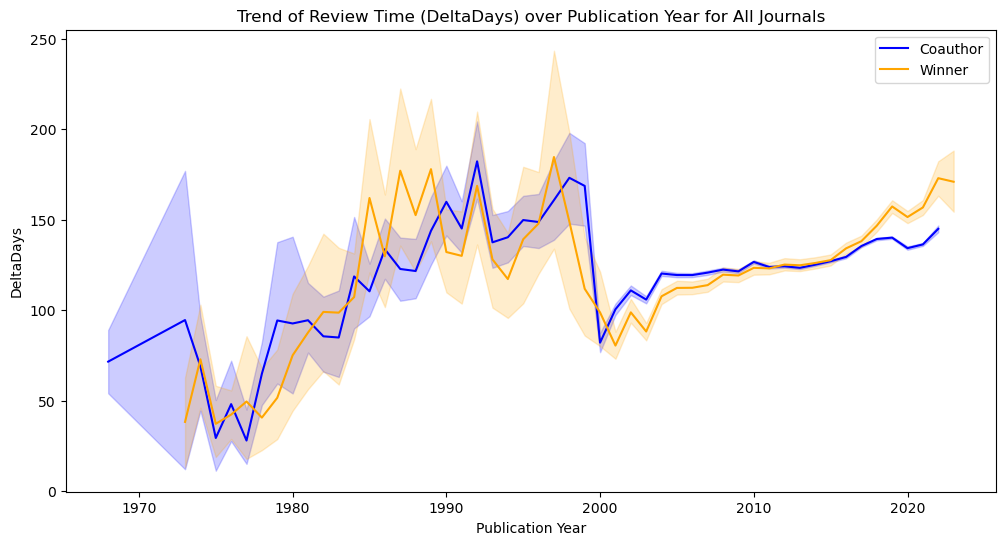

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.lineplot(x='PubYear', y='DeltaDays', data=df[df['if_winner'] == 0], label='Coauthor', color='blue')
sns.lineplot(x='PubYear', y='DeltaDays', data=df[df['if_winner'] == 1], label='Winner', color='orange')
plt.xlabel('Publication Year')
plt.ylabel('DeltaDays')
plt.title('Trend of Review Time (DeltaDays) over Publication Year for All Journals')
plt.legend()
plt.show()

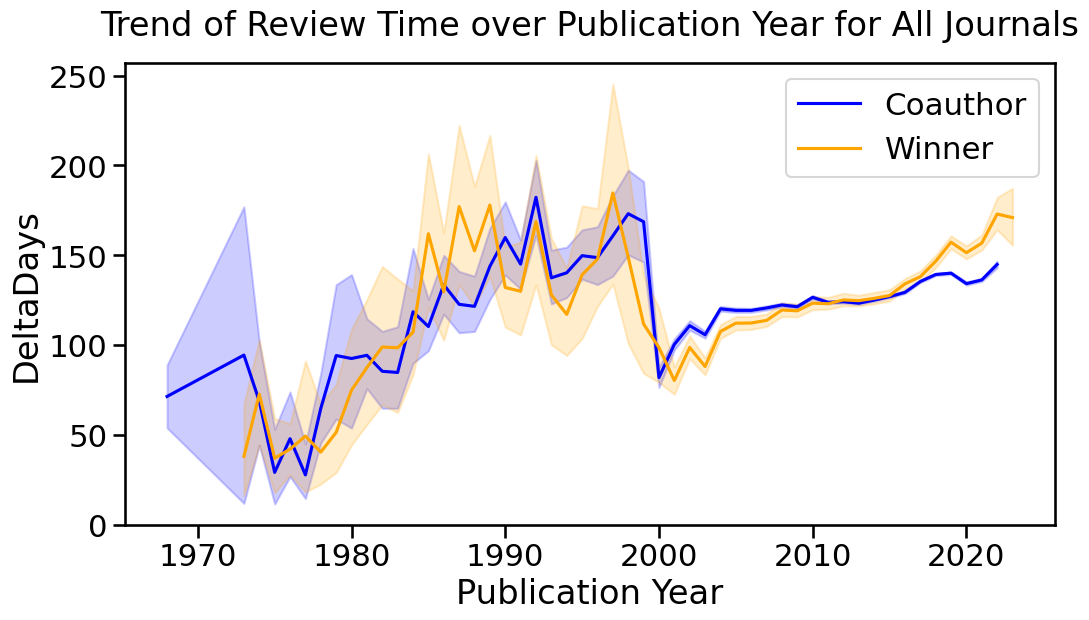

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context("talk", font_scale=1.35)
plt.figure(figsize=(12, 6))

sns.lineplot(x='PubYear', y='DeltaDays',
             data=df[df['if_winner'] == 0],
             label='Coauthor', color='blue')
sns.lineplot(x='PubYear', y='DeltaDays',
             data=df[df['if_winner'] == 1],
             label='Winner', color='orange')

plt.xlabel('Publication Year')
plt.ylabel('DeltaDays')
plt.title('Trend of Review Time over Publication Year for All Journals', pad=20)

plt.legend()
plt.show()


In [6]:
df1 = df[df['is_nature_index'] == 1]
df1

,group_id,author_id,if_winner,work_id,author_position,doi,pmid,JournalISSN,PubYear,DeltaDays,...,winner_count,cited_by_count,ref_num,first_pub_year,academic_experience,JournalISSN_clean,year_diff,is_nature_index,JIF,JIF5Years
3,1.0,A100328954,1,W2079983821,last,nature10500,21993758.0,1476-4687,2011.0,301.0,...,1,92,26,1968,43.0,14764687,5.0,1.0,50.5,54.4
4,1.0,A100328954,1,W2626909667,middle,s41467-017-00070-0,28623249.0,2041-1723,2017.0,11.0,...,1,43,34,1968,49.0,20411723,1.0,1.0,14.7,16.1
6,1.0,A100328954,1,W2023711487,last,nnano.2009.5,19350035.0,1748-3395,2009.0,156.0,...,1,118,15,1968,41.0,17483395,7.0,1.0,38.1,39.6
7,1.0,A100328954,1,W2146062744,middle,nmat2471,19525950.0,1476-4660,2009.0,78.0,...,1,125,31,1968,41.0,14764660,7.0,1.0,37.2,44.0
8,1.0,A100328954,1,W2082015621,last,nature08274,19727196.0,1476-4687,2009.0,130.0,...,1,703,24,1968,41.0,14764687,7.0,1.0,50.5,54.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1168796,1778.0,A2145135672,0,W2011025973,last,10.1289/ehp.10978,18560523.0,0091-6765,2008.0,112.0,...,0,24,35,1979,29.0,00916765,6.0,1.0,10.1,10.3
1168798,1778.0,A2022257047,0,W2430656774,middle,10.1038/ncomms11831,27291101.0,2041-1723,2016.0,139.0,...,0,208,57,1980,36.0,20411723,14.0,1.0,14.7,16.1
1168799,1778.0,A2022257047,0,W2430656774,middle,10.1038/ncomms11831,27291101.0,2041-1723,2016.0,139.0,...,0,208,57,1980,36.0,20411723,14.0,1.0,14.7,16.1
1168801,1778.0,A2175935238,0,W2774887741,last,10.1038/nature24488,29239352.0,1476-4687,2017.0,184.0,...,0,48,122,1970,47.0,14764687,15.0,1.0,50.5,54.4


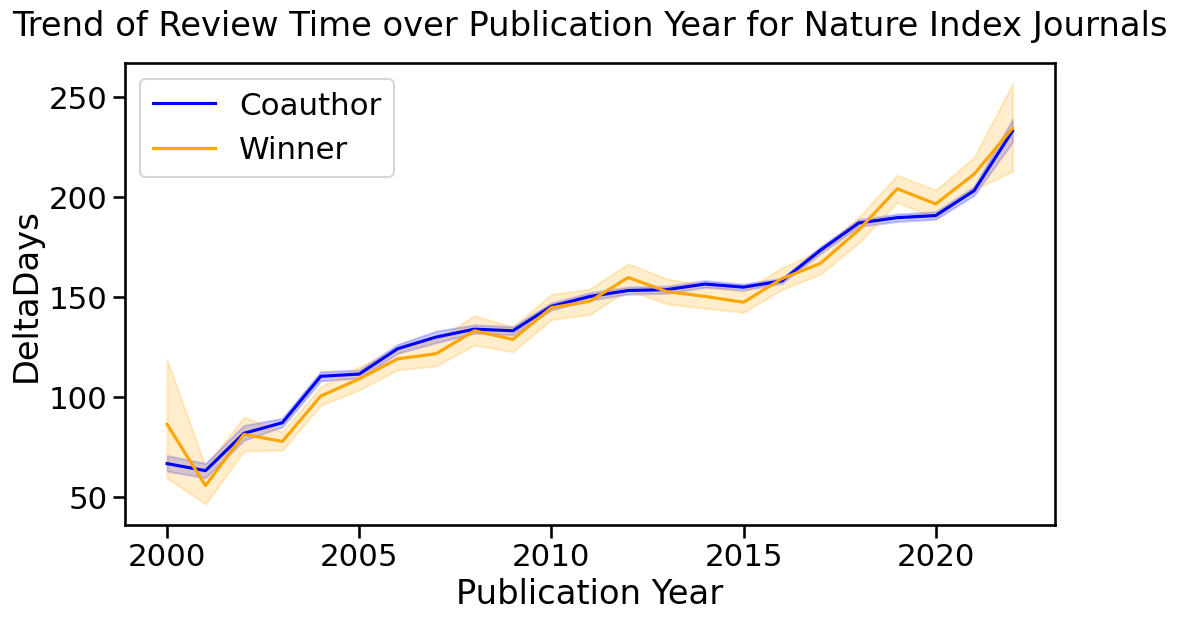

In [7]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='PubYear', y='DeltaDays', data=df1[(df1['if_winner'] == 0) & (df1['PubYear'] >= 2000)], label='Coauthor', color='blue')
sns.lineplot(x='PubYear', y='DeltaDays', data=df1[(df1['if_winner'] == 1) & (df1['PubYear'] >= 2000)], label='Winner', color='orange')
plt.xlabel('Publication Year')
plt.ylabel('DeltaDays')
plt.title('Trend of Review Time over Publication Year for Nature Index Journals', pad =20)
plt.legend()
plt.show()

In [8]:
df1 = df[df['is_nature_index'] == 0]
df1

,group_id,author_id,if_winner,work_id,author_position,doi,pmid,JournalISSN,PubYear,DeltaDays,...,winner_count,cited_by_count,ref_num,first_pub_year,academic_experience,JournalISSN_clean,year_diff,is_nature_index,JIF,JIF5Years
0,1.0,A100328954,1,W2064862591,last,j.bpj.2009.04.054,19619467.0,1542-0086,2009.0,34.0,...,1,15,46,1968,41.0,15420086,7.0,0.0,3.2,3.2
1,1.0,A100328954,1,W1948327735,last,gkv739,26184876.0,1362-4962,2015.0,64.0,...,1,3,19,1968,47.0,13624962,1.0,0.0,16.6,16.1
2,1.0,A100328954,1,W2761930832,last,j.chembiol.2017.08.018,28988948.0,2451-9448,2017.0,95.0,...,1,12,36,1968,49.0,24519448,1.0,0.0,6.6,8.2
5,1.0,A100328954,1,W1567090568,last,28998,9707114.0,2291-9694,2021.0,134.0,...,1,2266,36,1968,53.0,22919694,5.0,0.0,3.1,3.5
9,1.0,A100328954,1,W1656731888,last,16437,9923675.0,1438-8871,2020.0,248.0,...,1,666,26,1968,52.0,14388871,4.0,0.0,5.8,6.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1168802,1778.0,A2550302871,0,W2810788743,middle,10.1038/s41598-018-28503-w,29976935.0,2045-2322,2018.0,122.0,...,0,12,52,2001,17.0,20452322,16.0,0.0,3.8,4.3
1168803,1778.0,A1979552405,0,W2131927690,last,10.1017/s1431927606060491,16984669.0,1431-9276,2006.0,447.0,...,0,19,17,1992,14.0,14319276,4.0,0.0,2.9,3.4
1168805,1778.0,A2185106891,0,W2300775557,middle,10.1016/j.scitotenv.2016.03.079,26994806.0,1879-1026,2016.0,46.0,...,0,22,54,2000,16.0,18791026,14.0,0.0,8.2,8.6
1168806,1778.0,A2155499886,0,W2409721926,middle,10.1038/srep20159,26832223.0,2045-2322,2016.0,73.0,...,0,136,53,1971,45.0,20452322,14.0,0.0,3.8,4.3


In [9]:
df2 = df1[df1['PubYear'] == 2023]
df2

,group_id,author_id,if_winner,work_id,author_position,doi,pmid,JournalISSN,PubYear,DeltaDays,...,winner_count,cited_by_count,ref_num,first_pub_year,academic_experience,JournalISSN_clean,year_diff,is_nature_index,JIF,JIF5Years
3145,18.0,A1133887922,1,W1617092022,last,46925,10573413.0,2368-7959,2023.0,131.0,...,1,72,11,1973,50.0,23687959,10.0,0.0,4.8,5.1
34798,50.0,A130489364,1,W1671013354,last,41222,9242398.0,2561-326x,2023.0,187.0,...,2,10,0,1980,43.0,2561326X,18.0,0.0,2.0,NaN
34827,50.0,A130489364,1,W1571689838,middle,40645,9217159.0,2561-326x,2023.0,183.0,...,2,468,31,1980,43.0,2561326X,18.0,0.0,2.0,NaN
34840,50.0,A130489364,1,W1483422351,middle,41574,9252190.0,1929-073x,2023.0,250.0,...,3,323,30,1980,43.0,1929073X,18.0,0.0,1.9,2.2
37000,59.0,A1354385636,1,W1664439142,middle,46528,10586878.0,2292-9495,2023.0,127.0,...,2,723,25,1975,48.0,22929495,7.0,0.0,2.6,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1127783,1705.0,A67045253,1,W1612036080,last,43049,9202111.0,2369-2960,2023.0,79.0,...,1,4,2,1975,48.0,23692960,8.0,0.0,3.5,4.7
1134300,1715.0,A679456835,1,W2130603065,last,44188,10524633.0,1438-8871,2023.0,175.0,...,1,841,20,1977,46.0,14388871,30.0,0.0,5.8,6.7
1138675,1732.0,A710126269,1,W1566516389,first,41193,9242391.0,2561-326x,2023.0,172.0,...,1,1,0,1969,54.0,2561326X,41.0,0.0,2.0,NaN
1139478,1738.0,A723667461,1,W1610621306,middle,40582,9217153.0,2561-7605,2023.0,137.0,...,1,71,7,1971,52.0,25617605,6.0,0.0,5.0,NaN


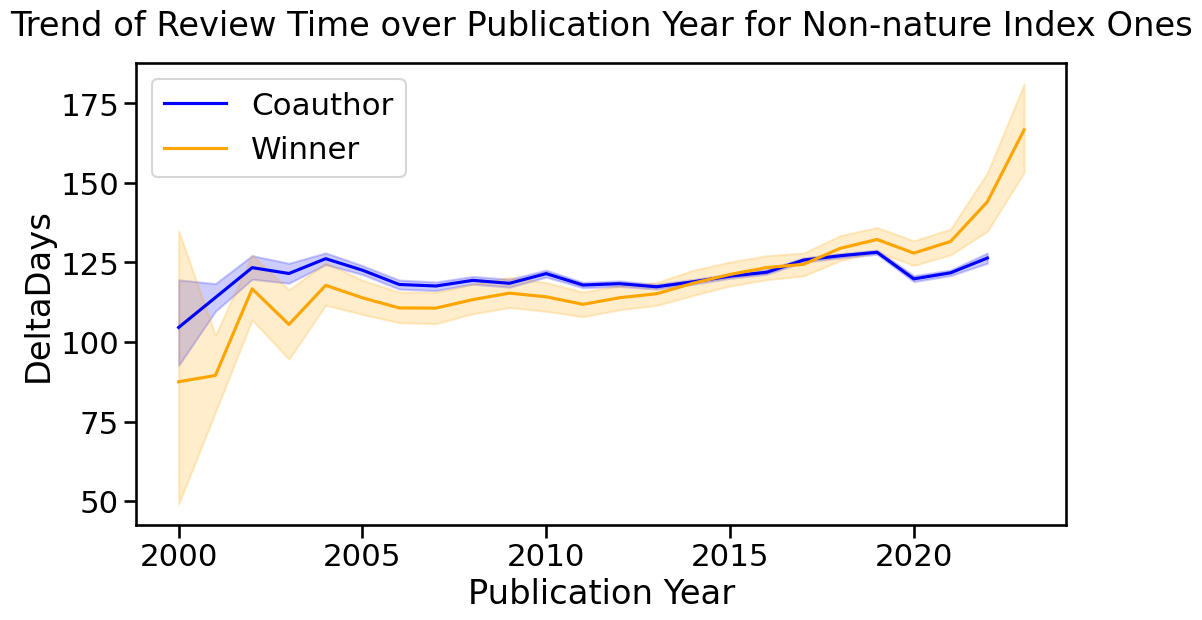

In [10]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='PubYear', y='DeltaDays', data=df1[(df1['if_winner'] == 0) & (df1['PubYear'] >= 2000)], label='Coauthor', color='blue')
sns.lineplot(x='PubYear', y='DeltaDays', data=df1[(df1['if_winner'] == 1) & (df1['PubYear'] >= 2000)], label='Winner', color='orange')
plt.xlabel('Publication Year')
plt.ylabel('DeltaDays')
plt.title('Trend of Review Time over Publication Year for Non-nature Index Ones', pad =20)
plt.legend()
plt.show()

In [11]:
target_issns1 = {'0028-0836', '1476-4687',  # Nature
                '0036-8075', '1095-9203',  # Science
                '0027-8424', '1091-6490'}  # PNAS

df_target1 = df[df['JournalISSN'].isin(target_issns1)].copy()

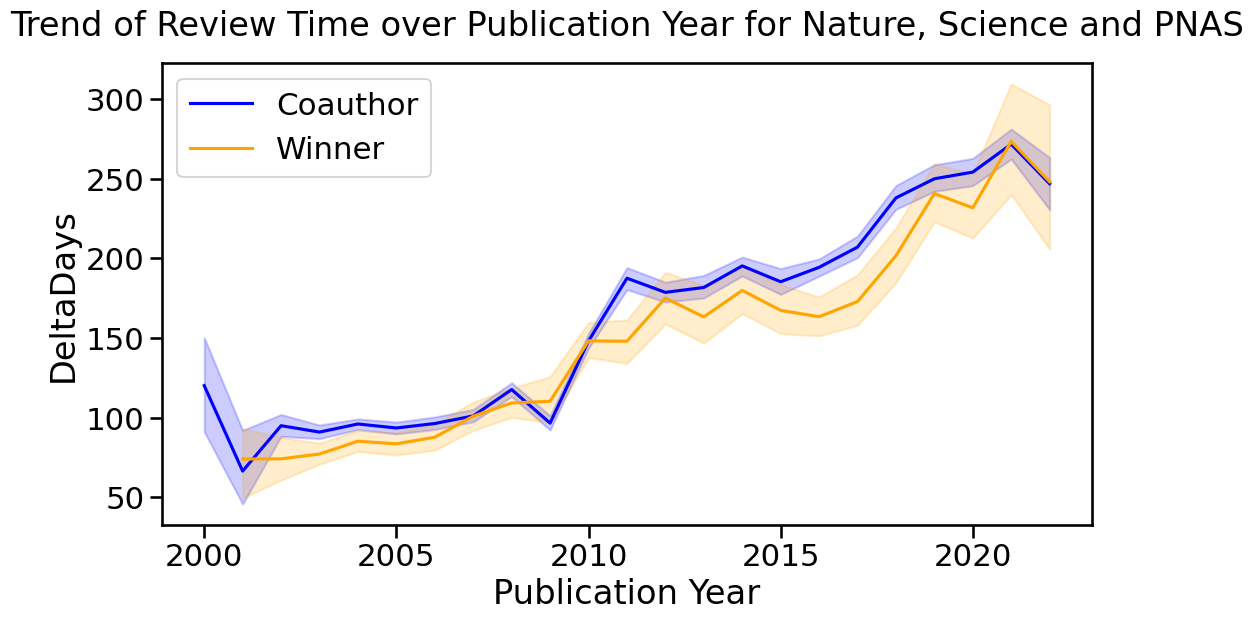

In [12]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='PubYear', y='DeltaDays', data=df_target1[(df_target1['if_winner'] == 0) & (df_target1['PubYear'] >= 2000)], label='Coauthor', color='blue')
sns.lineplot(x='PubYear', y='DeltaDays', data=df_target1[(df_target1['if_winner'] == 1) & (df_target1['PubYear'] >= 2000)], label='Winner', color='orange')
plt.xlabel('Publication Year')
plt.ylabel('DeltaDays')
plt.title('Trend of Review Time over Publication Year for Nature, Science and PNAS', pad =20)
plt.legend()
plt.show()

In [13]:
target_issns2 = {
    # Lancet
    '0028-0836', '1476-4687',  # ISSN and EISSN
    # JAMA
    '0098-7484', '1538-3598',  
    # NEJM
    '0028-4793', '1533-4406',  
    # BMJ
    '0959-8138', '1756-1833'    
}

df_target2 = df[df['JournalISSN'].isin(target_issns2)].copy()
df_target2

,group_id,author_id,if_winner,work_id,author_position,doi,pmid,JournalISSN,PubYear,DeltaDays,...,winner_count,cited_by_count,ref_num,first_pub_year,academic_experience,JournalISSN_clean,year_diff,is_nature_index,JIF,JIF5Years
3,1.0,A100328954,1,W2079983821,last,nature10500,21993758.0,1476-4687,2011.0,301.0,...,1,92,26,1968,43.0,14764687,5.0,1.0,50.5,54.4
8,1.0,A100328954,1,W2082015621,last,nature08274,19727196.0,1476-4687,2009.0,130.0,...,1,703,24,1968,41.0,14764687,7.0,1.0,50.5,54.4
22,1.0,A100328954,1,W2032813700,last,nature09026,20463734.0,1476-4687,2010.0,105.0,...,1,607,22,1968,42.0,14764687,6.0,1.0,50.5,54.4
103,1.0,A2443672252,0,W2007855820,middle,10.1038/nature12009,23535594.0,1476-4687,2013.0,138.0,...,0,276,40,1970,43.0,14764687,3.0,1.0,50.5,54.4
150,1.0,A2443672252,0,W3011517822,middle,10.1038/s41586-020-2098-y,32188941.0,1476-4687,2020.0,294.0,...,0,154,61,1970,50.0,14764687,4.0,1.0,50.5,54.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1168717,1778.0,A2159042405,0,W3036730421,middle,10.1038/s41586-020-2361-2,32555490.0,1476-4687,2020.0,220.0,...,0,47,34,1987,33.0,14764687,18.0,1.0,50.5,54.4
1168724,1778.0,A2100063418,0,W2887941197,middle,10.1038/s41586-018-0434-2,30127406.0,1476-4687,2018.0,322.0,...,0,49,34,1981,37.0,14764687,16.0,1.0,50.5,54.4
1168740,1778.0,A2076615123,0,W2143811190,middle,10.1038/nature05759,17507980.0,1476-4687,2007.0,269.0,...,0,109,30,1935,72.0,14764687,5.0,1.0,50.5,54.4
1168795,1778.0,A2022257047,0,W1971356330,middle,10.1038/nature01265,12466838.0,0028-0836,2002.0,155.0,...,0,119,14,1980,22.0,00280836,0.0,1.0,50.5,54.4


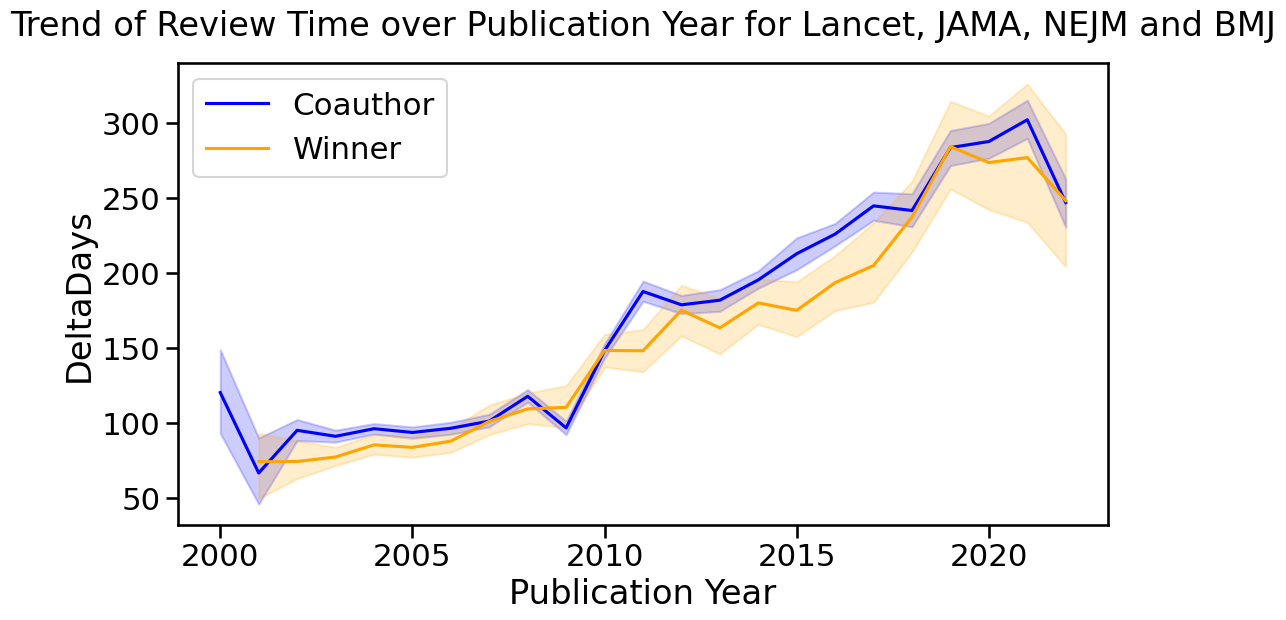

In [14]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='PubYear', y='DeltaDays', data=df_target2[(df_target2['if_winner'] == 0) & (df_target2['PubYear'] >= 2000)], label='Coauthor', color='blue')
sns.lineplot(x='PubYear', y='DeltaDays', data=df_target2[(df_target2['if_winner'] == 1) & (df_target2['PubYear'] >= 2000)], label='Winner', color='orange')
plt.xlabel('Publication Year')
plt.ylabel('DeltaDays')
plt.title('Trend of Review Time over Publication Year for Lancet, JAMA, NEJM and BMJ', pad =20)
plt.legend()
plt.show()

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
from matplotlib.lines import Line2D
warnings.filterwarnings('ignore')
plt.rcParams['text.usetex'] = False

warnings.filterwarnings('ignore')

df = pd.read_csv('final_group_pos_doipmid_puby_deltadays_field_tsize_top5_before0_after1_coauthor_wc0_natindex_fpy_aca_exp_jif_EISSN.csv')

df = df[(df['DeltaDays'] > 0) & (df['DeltaDays'] <= 20000)].copy()
df['year_diff'] = abs(df['PubYear'] - df['awardYear'])



df['is_nature_index'] = df['is_nature_index'].fillna(2).astype('category')
df['JournalISSN'] = df['JournalISSN'].fillna("Unknown")
df['author_position'] = pd.Categorical(df['author_position'], categories=["first", "middle", "last"])
df['field'] = df['field'].astype('category')
df['is_top5'] = df['is_top5'].astype('category')

def preprocess_data(data):
    data = data.copy()
    categorical_cols = ['author_position', 'is_top5', 'before_or_after', 'field']
    for col in categorical_cols:
        if col in data.columns:
            data[col] = data[col].astype('category')
    
    quantile_ranges = {'cited_by_count': 0.995, 'ref_num': 0.99,'JIF': 0.99, 'JIF5Years': 0.99}
    # quantile_ranges = { }
    for col, q in quantile_ranges.items():
        if col in data.columns:
            data = data[data[col] < data[col].quantile(q)]
    return data

df = preprocess_data(df)

df_nature = preprocess_data(df[df['is_nature_index'] == 1].copy())
df_nature

,group_id,author_id,if_winner,work_id,author_position,doi,pmid,JournalISSN,PubYear,DeltaDays,...,winner_count,cited_by_count,ref_num,first_pub_year,academic_experience,JournalISSN_clean,year_diff,is_nature_index,JIF,JIF5Years
4,1.0,A100328954,1,W2626909667,middle,s41467-017-00070-0,28623249.0,2041-1723,2017.0,11.0,...,1,43,34,1968,49.0,20411723,1.0,1.0,14.7,16.1
6,1.0,A100328954,1,W2023711487,last,nnano.2009.5,19350035.0,1748-3395,2009.0,156.0,...,1,118,15,1968,41.0,17483395,7.0,1.0,38.1,39.6
12,1.0,A100328954,1,W2602323869,last,nchem.2745,28754940.0,1755-4349,2017.0,336.0,...,1,39,21,1968,49.0,17554349,1.0,1.0,19.2,22.0
14,1.0,A100328954,1,W2989653485,middle,s41557-019-0369-8,31767992.0,1755-4349,2019.0,197.0,...,1,72,48,1968,51.0,17554349,3.0,1.0,19.2,22.0
17,1.0,A100328954,1,W2094737302,last,nnano.2014.102,24880222.0,1748-3395,2014.0,217.0,...,1,64,27,1968,46.0,17483395,2.0,1.0,38.1,39.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1168779,1778.0,A2112245878,0,W2802154306,last,10.1038/s41467-018-03564-7,29662220.0,2041-1723,2018.0,76.0,...,0,44,38,1993,25.0,20411723,16.0,1.0,14.7,16.1
1168793,1778.0,A2076615123,0,W3108308052,last,10.1126/sciadv.abd1387,33239296.0,2375-2548,2020.0,126.0,...,0,19,100,1935,85.0,23752548,18.0,1.0,11.7,13.7
1168796,1778.0,A2145135672,0,W2011025973,last,10.1289/ehp.10978,18560523.0,0091-6765,2008.0,112.0,...,0,24,35,1979,29.0,00916765,6.0,1.0,10.1,10.3
1168798,1778.0,A2022257047,0,W2430656774,middle,10.1038/ncomms11831,27291101.0,2041-1723,2016.0,139.0,...,0,208,57,1980,36.0,20411723,14.0,1.0,14.7,16.1


In [16]:
df_nonnature = preprocess_data(df[df['is_nature_index'] == 0].copy())

df_nonnature

,group_id,author_id,if_winner,work_id,author_position,doi,pmid,JournalISSN,PubYear,DeltaDays,...,winner_count,cited_by_count,ref_num,first_pub_year,academic_experience,JournalISSN_clean,year_diff,is_nature_index,JIF,JIF5Years
0,1.0,A100328954,1,W2064862591,last,j.bpj.2009.04.054,19619467.0,1542-0086,2009.0,34.0,...,1,15,46,1968,41.0,15420086,7.0,0.0,3.2,3.2
1,1.0,A100328954,1,W1948327735,last,gkv739,26184876.0,1362-4962,2015.0,64.0,...,1,3,19,1968,47.0,13624962,1.0,0.0,16.6,16.1
2,1.0,A100328954,1,W2761930832,last,j.chembiol.2017.08.018,28988948.0,2451-9448,2017.0,95.0,...,1,12,36,1968,49.0,24519448,1.0,0.0,6.6,8.2
13,1.0,A100328954,1,W2027489696,last,j.jmgm.2006.03.005,16630733.0,1093-3263,2006.0,79.0,...,1,64,32,1968,38.0,10933263,10.0,0.0,2.7,2.4
15,1.0,A100328954,1,W2021237069,last,j.biosystems.2009.07.004,19607875.0,1872-8324,2009.0,119.0,...,1,20,19,1968,41.0,18728324,7.0,0.0,2.0,1.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1168802,1778.0,A2550302871,0,W2810788743,middle,10.1038/s41598-018-28503-w,29976935.0,2045-2322,2018.0,122.0,...,0,12,52,2001,17.0,20452322,16.0,0.0,3.8,4.3
1168803,1778.0,A1979552405,0,W2131927690,last,10.1017/s1431927606060491,16984669.0,1431-9276,2006.0,447.0,...,0,19,17,1992,14.0,14319276,4.0,0.0,2.9,3.4
1168805,1778.0,A2185106891,0,W2300775557,middle,10.1016/j.scitotenv.2016.03.079,26994806.0,1879-1026,2016.0,46.0,...,0,22,54,2000,16.0,18791026,14.0,0.0,8.2,8.6
1168806,1778.0,A2155499886,0,W2409721926,middle,10.1038/srep20159,26832223.0,2045-2322,2016.0,73.0,...,0,136,53,1971,45.0,20452322,14.0,0.0,3.8,4.3


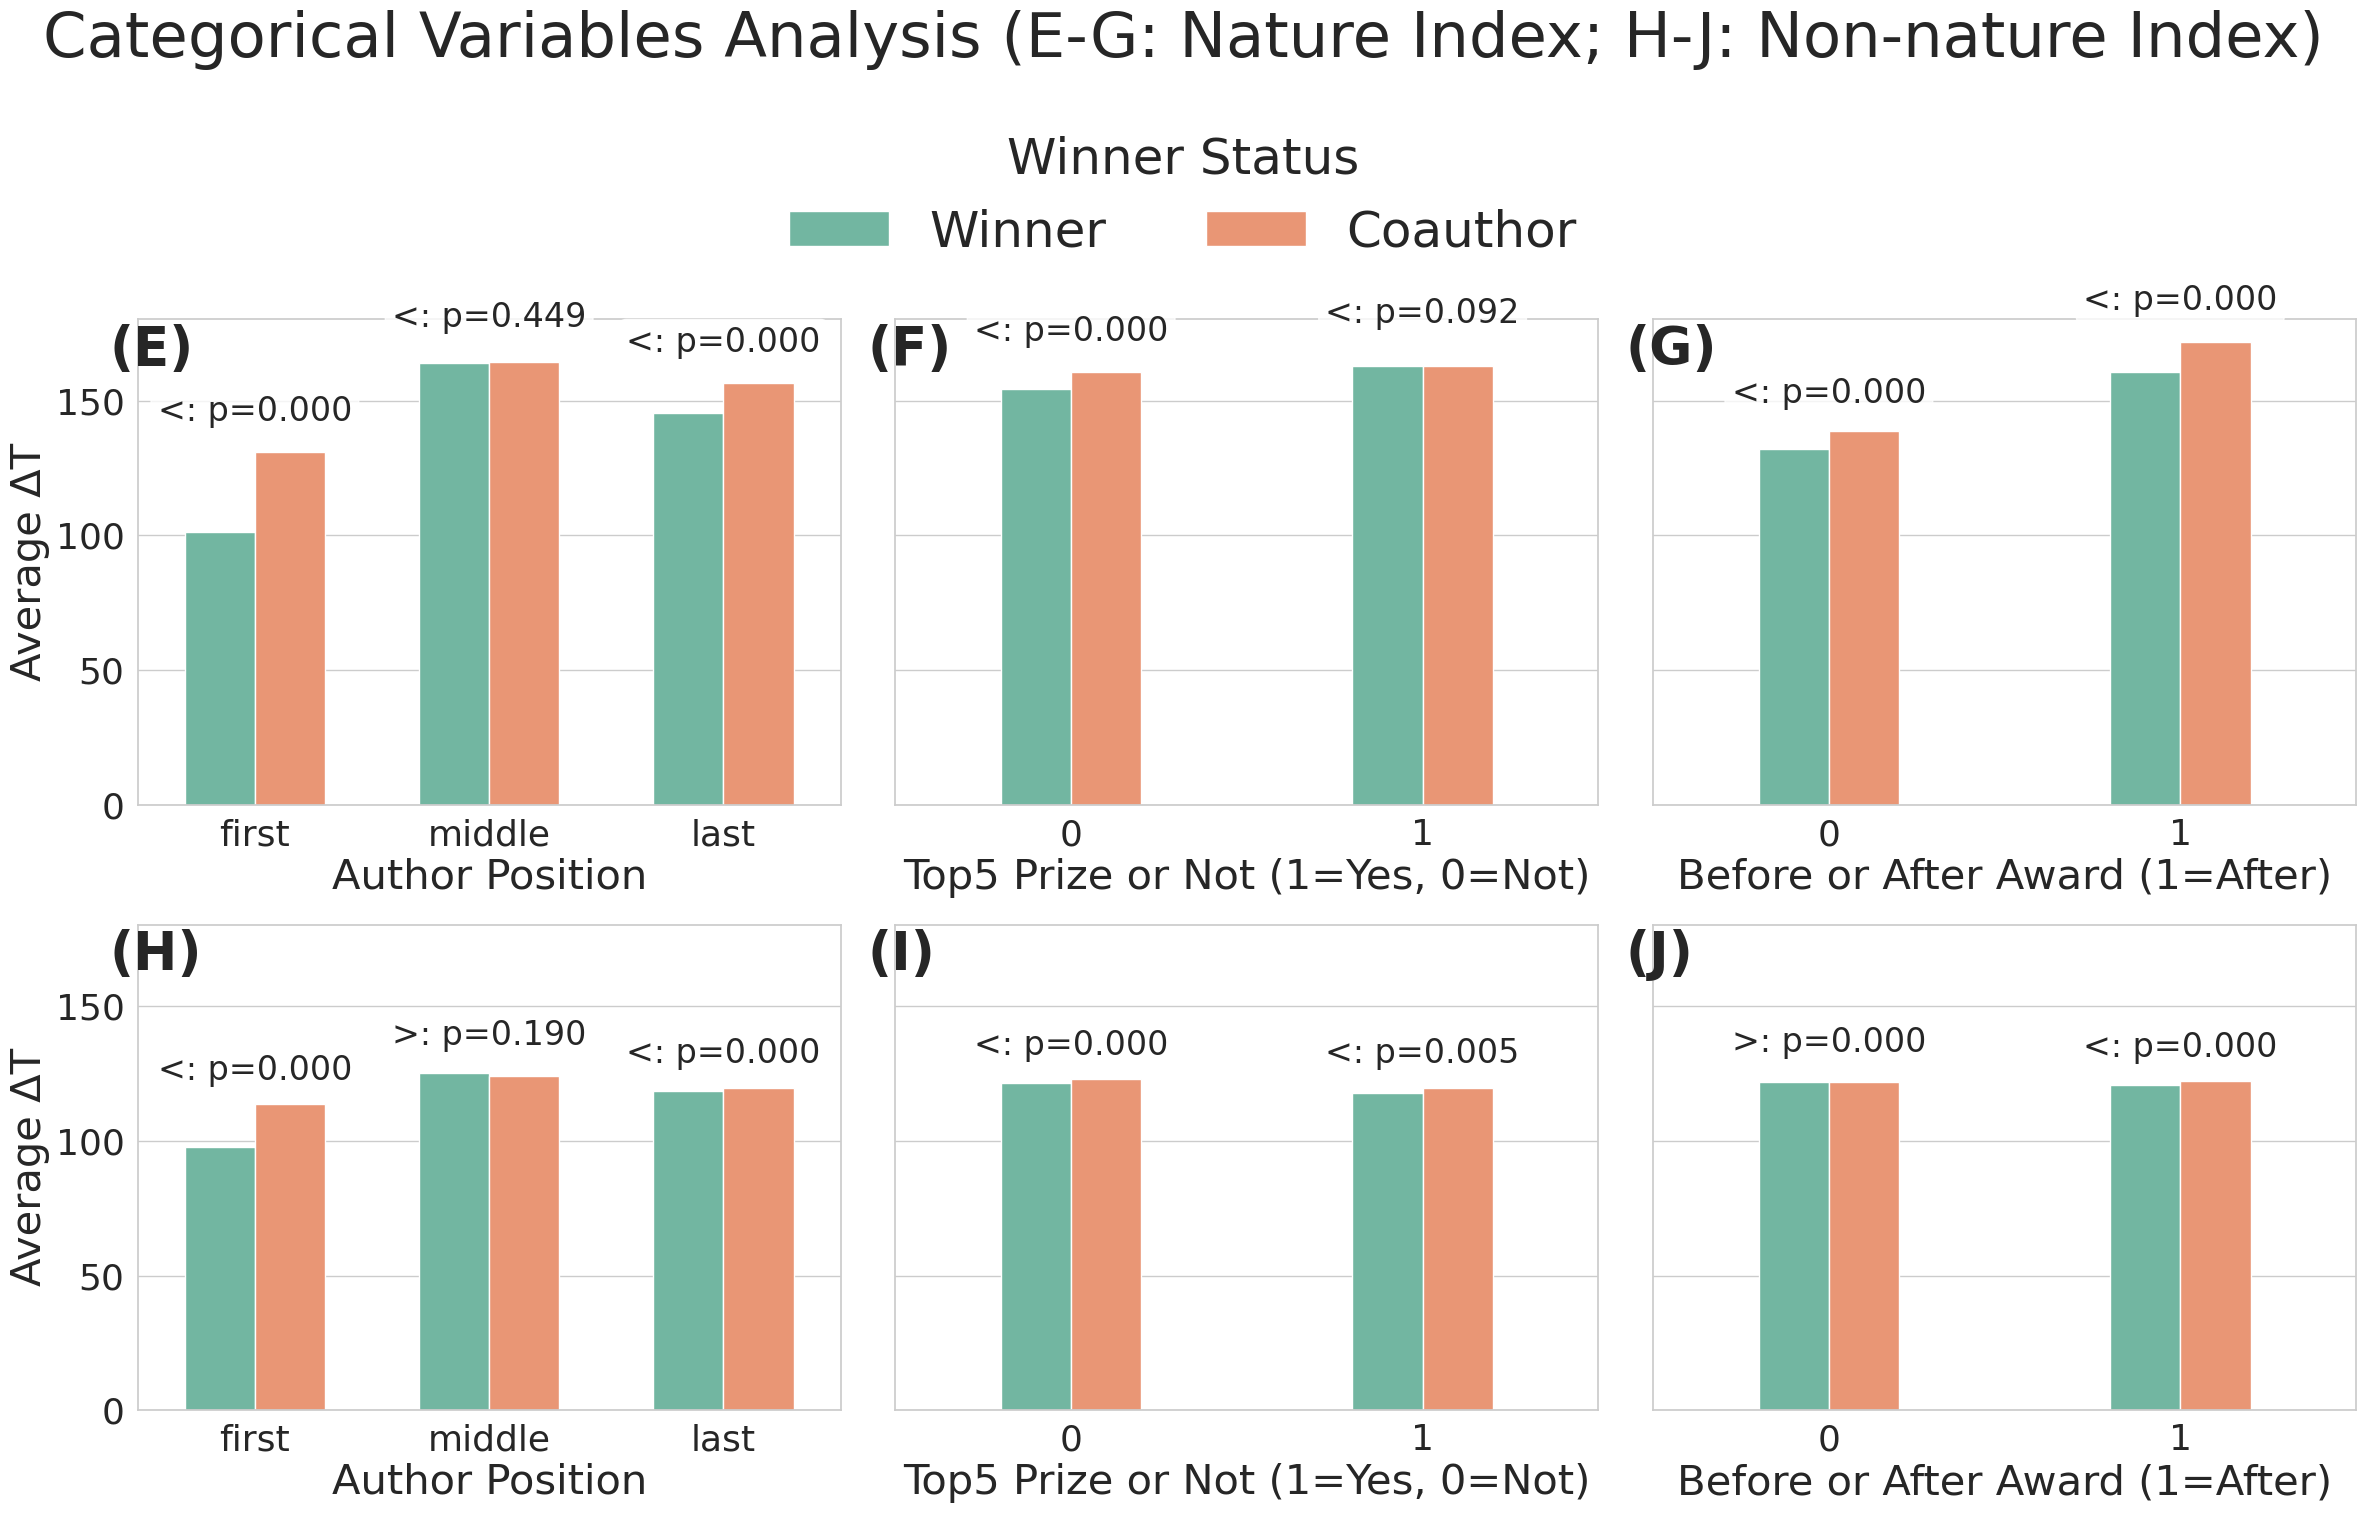

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
from matplotlib.lines import Line2D
warnings.filterwarnings('ignore')
plt.rcParams['text.usetex'] = False

warnings.filterwarnings('ignore')

df = pd.read_csv('final_group_pos_doipmid_puby_deltadays_field_tsize_top5_before0_after1_coauthor_wc0_natindex_fpy_aca_exp_jif_EISSN.csv')

df = df[(df['DeltaDays'] > 0) & (df['DeltaDays'] <= 20000)].copy()
df['year_diff'] = abs(df['PubYear'] - df['awardYear'])

df['is_nature_index'] = df['is_nature_index'].fillna(2).astype('category')
df['JournalISSN'] = df['JournalISSN'].fillna("Unknown")
df['author_position'] = pd.Categorical(df['author_position'], categories=["first", "middle", "last"])
df['field'] = df['field'].astype('category')
df['is_top5'] = df['is_top5'].astype('category')

def preprocess_data(data):
    data = data.copy()
    categorical_cols = ['author_position', 'is_top5', 'before_or_after', 'field']
    for col in categorical_cols:
        if col in data.columns:
            data[col] = data[col].astype('category')
    
    quantile_ranges = {'cited_by_count': 0.995, 'ref_num': 0.99,'JIF': 0.99, 'JIF5Years': 0.99}
    # quantile_ranges = { }
    for col, q in quantile_ranges.items():
        if col in data.columns:
            data = data[data[col] < data[col].quantile(q)]
    return data

df = preprocess_data(df)

df_nature = preprocess_data(df[df['is_nature_index'] == 1].copy())
df_nonnature = preprocess_data(df[df['is_nature_index'] == 0].copy())

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def ci95(x):
    n = x.count()
    if n <= 1:
        return np.nan
    sem = stats.sem(x, nan_policy='omit')
    t_val = stats.t.ppf(1 - 0.025, n - 1)
    return sem * t_val

cat_vars = ['author_position', 'is_top5', 'before_or_after']

plt.rcParams.update({
    'font.size': 24,               
    'axes.titlesize': 30,           
    'axes.labelsize': 27,          
    'xtick.labelsize': 21,        
    'ytick.labelsize': 21,
    'legend.fontsize': 21,         
    'legend.title_fontsize': 24,   
    'figure.titlesize': 36         
})

sns.set_theme(style="whitegrid", font_scale=1.5)

fig, axes = plt.subplots(2, 3, figsize=(24, 16), sharey=True)
fig.suptitle(
    "Categorical Variables Analysis (E-G: Nature Index; H-J: Non-nature Index)",
    fontsize=45, y=0.95
)

palette = sns.color_palette("Set2", 2)
letters = ['E','F','G','H','I','J']

var_labels = {
    'author_position': 'Author Position',
    'is_top5': 'Top5 Prize or Not (1=Yes, 0=Not)',
    'before_or_after': 'Before or After Award (1=After)'
}

def draw_panel(data, var, ax, letter):
    grouped = (
        data.groupby([var, 'if_winner'])['DeltaDays']
            .agg(mean='mean', ci=lambda x: ci95(x))
            .reset_index()
    )
    
    n_categories = len(data[var].cat.categories)
    
    if n_categories == 3:  # author_position
        width = 0.6
    else:  # is_top5 and before_or_after
        width = 0.4
    
    sns.barplot(
        x=var, y='mean', hue='if_winner',
        data=grouped, ax=ax,
        order=data[var].cat.categories,
        hue_order=[1,0],
        palette=palette, ci=None,
        width=width  
    )

    xt = ax.get_xticks()
    for i, cat in enumerate(data[var].cat.categories):
        row1 = grouped[(grouped[var]==cat)&(grouped['if_winner']==1)]
        row0 = grouped[(grouped[var]==cat)&(grouped['if_winner']==0)]
        m1, ci1 = row1['mean'].iloc[0], row1['ci'].iloc[0]
        m0, ci0 = row0['mean'].iloc[0], row0['ci'].iloc[0]
        
        p = stats.ttest_ind(
            np.log(data[(data[var]==cat)&(data['if_winner']==1)]['DeltaDays']),
            np.log(data[(data[var]==cat)&(data['if_winner']==0)]['DeltaDays']),
            alternative='less'
        ).pvalue
        
        if m1 < m0:
            symbol = '<'
        else:
            symbol = '>'
            
        p_str = f"p={p:.3f}"
            
        y_max = max(m1+ci1, m0+ci0)
        ax.text(
            xt[i], y_max * 1.05,
            f"{symbol}: {p_str}",
            ha='center', va='bottom',
            fontsize=24,  
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8)
        )

    ax.text(
        -0.04, 0.99, f'({letter})',  
        transform=ax.transAxes,
        fontsize=38,
        fontweight='bold', va='top'
    )

    ax.set_xlabel(var_labels[var], fontsize=30)
    ax.set_ylabel('Average ΔT', fontsize=30)

    ax.tick_params(axis='x', labelsize=26)  
    ax.tick_params(axis='y', labelsize=26)

    ax.get_legend().remove()


for i, var in enumerate(cat_vars):
    draw_panel(df_nature, var, axes[0, i], letters[i])
for i, var in enumerate(cat_vars):
    draw_panel(df_nonnature, var, axes[1, i], letters[3 + i])

handles, _ = axes[0,0].get_legend_handles_labels()
fig.legend(
    handles, ['Winner', 'Coauthor'],
    title='Winner Status',
    loc='upper center',
    ncol=2,
    bbox_to_anchor=(0.5, 0.90),
    frameon=False,
    fontsize=36,         
    title_fontsize=36    
)

plt.tight_layout(rect=[0, 0, 1, 0.85])

plt.savefig("combined_categorical_bigfont_legend_top_v13.png", dpi=1000, bbox_inches='tight')
plt.show()

# Table 1

In [18]:
import pandas as pd
import numpy as np

combined_data = pd.read_csv(
    'final_group_pos_doipmid_puby_deltadays_field_tsize_top5_before0_after1_coauthor_wc0_natindex_fpy_aca_exp_jif_EISSN.csv',
    low_memory=False
)
mask = (combined_data['DeltaDays'] > 0) & (combined_data['DeltaDays'] <= 10000)
combined_data = combined_data[mask].copy()

combined_data['log_DeltaDays'] = np.log1p(combined_data['DeltaDays'])
combined_data['year_diff'] = abs(combined_data['PubYear'] - combined_data['awardYear']) # fixed
combined_data['academic_experience'] = combined_data['PubYear'] - combined_data['first_pub_year']

author_position_mapping = {'last': 0, 'middle': 1, 'first': 2}
combined_data['author_position_encoded'] = combined_data['author_position'].map(author_position_mapping)

field_mapping = {
    'Art': 0, 'Biology': 1, 'Business': 2, 'Chemistry': 3,
    'Computer science': 4, 'Economics': 5, 'Environmental science': 6,
    'Geography': 7, 'Geology': 8, 'History': 9, 'Materials science': 10,
    'Mathematics': 11, 'Medicine': 12, 'Philosophy': 13, 'Physics': 14,
    'Political science': 15, 'Psychology': 16, 'Sociology': 17
}
combined_data['field_encoded'] = combined_data['field'].map(field_mapping)

grouping_config = {
    'teamsize':      {'bins': [1, 3, 6, np.inf],    'labels': ['Small [1-3)', 'Medium [3-6)', 'Large [6+)']},
    'JIF':           {'bins': [0, 10, 50, np.inf],  'labels': ['Low [0-10)', 'Med [10-50)', 'High [50+)']},
    'PubYear':       {'bins': [-np.inf, 2000, 2015, np.inf], 'labels': ['<2000', '2000-2015', '2015+']},
    'ref_num':       {'bins': [0,25,100, np.inf],   'labels': ['Few', 'Moderate', 'Many']},
    'cited_by_count':{'bins': [0,10,100,1000,np.inf],'labels': ['Low','Mod','High','Very High']},
    'year_diff':     {'bins': [0,3,np.inf],         'labels': ['Close','Far']},
    'academic_experience':{'bins': [-1,15,30,np.inf],'labels':['Junior','Mid','Senior']},
    'field':           {'is_categorical': True},
    'author_position': {'is_categorical': True},
    'is_nature_index': {'is_categorical': True},
    'is_top5':         {'is_categorical': True},    
    'before_or_after':         {'is_categorical': True},

    
}

def get_stats(data, group_col):
    stats = []
    for grp, sub in data.groupby(group_col, observed=True):
        w = sub.loc[sub['if_winner']==1, 'DeltaDays']
        c = sub.loc[sub['if_winner']==0, 'DeltaDays']
        def agg(x):
            return {
                'min': x.min(), '25%': x.quantile(0.25),
                'mean': x.mean(), 'median': x.median(),
                '75%': x.quantile(0.75), 'max': x.max()
            }
        stats.append({
            'Variable': group_col,
            'Group': grp,
            **{f'winner_{k}': v for k,v in agg(w).items()},
            **{f'coauthor_{k}': v for k,v in agg(c).items()}
        })
    return pd.DataFrame(stats)

all_stats = []
for var, cfg in grouping_config.items():
    if cfg.get('is_categorical'):
        stats_df = get_stats(combined_data, var)
        stats_df['Variable'] = var.title().replace('_',' ')
    else:
        grp = pd.cut(combined_data[var], bins=cfg['bins'], labels=cfg['labels'], right=False)
        tmp = combined_data.assign(**{f'{var}_grp': grp})
        stats_df = get_stats(tmp, f'{var}_grp')
        stats_df['Variable'] = var.title().replace('_',' ')
    all_stats.append(stats_df)

full_stats = pd.concat(all_stats, ignore_index=True)

cols = ['Variable','Group'] + \
       [f'winner_{m}' for m in ['min','25%','mean','median','75%','max']] + \
       [f'coauthor_{m}' for m in ['min','25%','mean','median','75%','max']]
full_stats = full_stats[cols]
pd.set_option('display.float_format','{:.2f}'.format)
#display(full_stats)


In [19]:
metrics = ['min', '25%', 'mean', 'median', '75%', 'max']
cols = ['Variable', 'Group'] 
for m in metrics:
    cols.extend([f'winner_{m}', f'coauthor_{m}'])  

full_stats = full_stats[cols]  
pd.set_option('display.float_format','{:.2f}'.format)
full_stats

,Variable,Group,winner_min,coauthor_min,winner_25%,coauthor_25%,winner_mean,coauthor_mean,winner_median,coauthor_median,winner_75%,coauthor_75%,winner_max,coauthor_max
0,Teamsize,Small [1-3),1.00,1.00,41.00,41.00,101.19,98.69,76.00,76.00,130.00,130.00,1611.00,1691.00
1,Teamsize,Medium [3-6),1.00,1.00,58.00,59.00,122.37,120.83,98.00,100.00,157.00,157.00,1238.00,3756.00
2,Teamsize,Large [6+),1.00,1.00,71.00,70.00,141.33,134.08,118.00,113.00,181.00,172.00,2214.00,4151.00
3,Jif,Low [0-10),1.00,1.00,59.00,63.00,121.72,122.36,99.00,104.00,157.00,158.00,2214.00,3987.00
4,Jif,Med [10-50),1.00,1.00,82.00,84.00,158.22,159.50,134.00,137.00,203.00,206.00,1530.00,2696.00
5,Jif,High [50+),1.00,1.00,73.00,80.00,159.42,172.77,121.00,135.00,205.75,226.00,2002.00,1377.00
6,Pubyear,<2000,1.00,1.00,56.00,61.00,132.53,139.62,104.00,113.00,179.00,188.00,663.00,939.00
7,Pubyear,2000-2015,1.00,1.00,58.00,64.00,118.76,122.70,98.00,104.00,154.00,158.00,1530.00,4151.00
8,Pubyear,2015+,1.00,1.00,70.00,68.00,145.20,134.58,119.00,113.00,188.00,174.00,2214.00,3843.00
9,Ref Num,Few,1.00,1.00,40.00,52.00,101.21,109.55,80.00,91.00,136.00,144.00,1846.00,4151.00


In [20]:
metrics = ['min', '25%', 'mean', 'median', '75%', 'max']

for metric in metrics:
    full_stats[metric] = full_stats[[f'winner_{metric}', f'coauthor_{metric}']].apply(tuple, axis=1)


full_stats = full_stats.drop(columns=[f'winner_{m}' for m in metrics] + [f'coauthor_{m}' for m in metrics])
full_stats = full_stats[['Variable', 'Group'] + metrics]

def format_tuple(t):
    return (f"{t[0]:.2f}", f"{t[1]:.2f}")

for metric in metrics:
    full_stats[metric] = full_stats[metric].apply(format_tuple)

pd.set_option('display.max_columns', None)

In [21]:
def format_tuple(t):
    return (f"{float(t[0]):.2f}", f"{float(t[1]):.2f}")

final_df = full_stats.copy()

column_rename = {
    'min': 'Review Time in Days (Winner, Coauthor) - Min',
    '25%': 'Review Time in Days (Winner, Coauthor) - 25th%',
    'mean': 'Review Time in Days (Winner, Coauthor) - Mean',
    'median': 'Review Time in Days (Winner, Coauthor) - Median',
    '75%': 'Review Time in Days (Winner, Coauthor) - 75th%',
    'max': 'Review Time in Days (Winner, Coauthor) - Max'
}
final_df = final_df.rename(columns=column_rename)

for col in column_rename.values():
    final_df[col] = final_df[col].apply(format_tuple)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.colheader_justify', 'center')


In [22]:
display(final_df)

,Variable,Group,"Review Time in Days (Winner, Coauthor) - Min","Review Time in Days (Winner, Coauthor) - 25th%","Review Time in Days (Winner, Coauthor) - Mean","Review Time in Days (Winner, Coauthor) - Median","Review Time in Days (Winner, Coauthor) - 75th%","Review Time in Days (Winner, Coauthor) - Max"
0,Teamsize,Small [1-3),"(1.00, 1.00)","(41.00, 41.00)","(101.19, 98.69)","(76.00, 76.00)","(130.00, 130.00)","(1611.00, 1691.00)"
1,Teamsize,Medium [3-6),"(1.00, 1.00)","(58.00, 59.00)","(122.37, 120.83)","(98.00, 100.00)","(157.00, 157.00)","(1238.00, 3756.00)"
2,Teamsize,Large [6+),"(1.00, 1.00)","(71.00, 70.00)","(141.33, 134.08)","(118.00, 113.00)","(181.00, 172.00)","(2214.00, 4151.00)"
3,Jif,Low [0-10),"(1.00, 1.00)","(59.00, 63.00)","(121.72, 122.36)","(99.00, 104.00)","(157.00, 158.00)","(2214.00, 3987.00)"
4,Jif,Med [10-50),"(1.00, 1.00)","(82.00, 84.00)","(158.22, 159.50)","(134.00, 137.00)","(203.00, 206.00)","(1530.00, 2696.00)"
5,Jif,High [50+),"(1.00, 1.00)","(73.00, 80.00)","(159.42, 172.77)","(121.00, 135.00)","(205.75, 226.00)","(2002.00, 1377.00)"
6,Pubyear,<2000,"(1.00, 1.00)","(56.00, 61.00)","(132.53, 139.62)","(104.00, 113.00)","(179.00, 188.00)","(663.00, 939.00)"
7,Pubyear,2000-2015,"(1.00, 1.00)","(58.00, 64.00)","(118.76, 122.70)","(98.00, 104.00)","(154.00, 158.00)","(1530.00, 4151.00)"
8,Pubyear,2015+,"(1.00, 1.00)","(70.00, 68.00)","(145.20, 134.58)","(119.00, 113.00)","(188.00, 174.00)","(2214.00, 3843.00)"
9,Ref Num,Few,"(1.00, 1.00)","(40.00, 52.00)","(101.21, 109.55)","(80.00, 91.00)","(136.00, 144.00)","(1846.00, 4151.00)"
